In [1]:
# Cell 1: Setup and Utilities
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import qr, svd, LinAlgError, eigh
from scipy.sparse.linalg import LinearOperator, eigsh
import os

os.makedirs('figureAKLT', exist_ok=True)
dtype = np.complex128

def truncated_svd(M, D_max, eps=1e-12, eps_abs=1e-14):
    """Truncated SVD with tolerance control."""
    try:
        U, s, Vh = svd(M, full_matrices=False, lapack_driver='gesdd')
    except LinAlgError:
        U, s, Vh = svd(M, full_matrices=False, lapack_driver='gesvd')
    
    if len(s) == 0:
        return U, np.zeros(0), Vh, 0.0
    
    s_max = s[0]
    if s_max < eps_abs:
        D_new = 1
    else:
        D_new = np.sum(s > max(eps * s_max, eps_abs))
    
    D_new = min(D_new, D_max, len(s))
    trunc_error = np.sum(s[D_new:]**2) if D_new < len(s) else 0.0
    
    return U[:, :D_new], s[:D_new], Vh[:D_new, :], trunc_error

def check_canonical(A, direction='left'):
    """Verify canonical condition."""
    D_left, d, D_right = A.shape
    if direction == 'left':
        A_mat = A.reshape((D_left * d, D_right), order='C')
        eye = np.eye(D_right, dtype=A.dtype)
        diff = np.linalg.norm(A_mat.conj().T @ A_mat - eye)
    else:
        A_mat = A.reshape((D_left, d * D_right), order='C')
        eye = np.eye(D_left, dtype=A.dtype)
        diff = np.linalg.norm(A_mat @ A_mat.conj().T - eye)
    return diff

In [2]:
# Cell 2: MPS Class
class MPS:
    def __init__(self, L, d, D_max, dtype=np.complex128):
        self.L = L
        self.d = d
        self.D_max = D_max
        self.dtype = dtype
        self.Ms = []
        
        D_prev = 1
        for i in range(L):
            if i == L - 1:
                D_curr = 1
            else:
                D_curr = min(D_max, d**(L - i - 1), d * D_prev, D_max)
                D_curr = max(1, D_curr)
            
            M = np.random.randn(D_prev, d, D_curr).astype(dtype) + \
                1j * np.random.randn(D_prev, d, D_curr).astype(dtype)
            self.Ms.append(M)
            D_prev = D_curr
    
    def left_canonicalize(self):
        """Left canonicalization using QR."""
        C = np.eye(1, dtype=self.dtype)
        for i in range(self.L - 1):
            M = self.Ms[i]
            D_left, d, D_right = M.shape
            M_tilde = np.tensordot(C, M, axes=([1], [0]))
            M_mat = M_tilde.reshape((-1, D_right), order='C')
            
            if M_mat.shape[0] >= M_mat.shape[1]:
                Q, R, P = qr(M_mat, pivoting=True, mode='economic')
                signs = np.sign(np.diag(R).real)
                signs[signs == 0] = 1
                Q = Q * signs[np.newaxis, :]
                R = signs[:, np.newaxis] * R
                D_new = Q.shape[1]
            else:
                Q, R = qr(M_mat, mode='economic')
                D_new = Q.shape[1]
            
            A = Q.reshape((D_left, d, D_new), order='C')
            self.Ms[i] = A
            C = R
        
        M_last = self.Ms[-1]
        M_last_tilde = np.tensordot(C, M_last, axes=([1], [0]))
        self.Ms[-1] = M_last_tilde
    
    def right_canonicalize(self):
        """Right canonicalization using SVD."""
        C = np.eye(1, dtype=self.dtype)
        for i in range(self.L - 1, 0, -1):
            M = self.Ms[i]
            D_left, d, D_right = M.shape
            
            if C.shape[0] != D_right:
                if C.shape == (1, 1):
                    M_tilde = M * C[0, 0]
                else:
                    M_tilde = np.tensordot(M, C, axes=([2], [0]))
            else:
                M_tilde = np.tensordot(M, C, axes=([2], [0]))
            
            M_mat = M_tilde.reshape((D_left, -1), order='C')
            
            try:
                U, s, Vh = svd(M_mat, full_matrices=False, lapack_driver='gesdd')
            except LinAlgError:
                U, s, Vh = svd(M_mat, full_matrices=False, lapack_driver='gesvd')
            
            D_new = min(len(s), self.D_max)
            s = s[:D_new]
            Vh = Vh[:D_new, :]
            
            B = Vh.reshape((D_new, d, D_right), order='C')
            self.Ms[i] = B
            
            C = U[:, :D_new] @ np.diag(s)
        
        self.Ms[0] = np.tensordot(self.Ms[0], C, axes=([2], [0]))

In [3]:
# Cell 3: MPO Class
class MPO:
    def __init__(self, L, d, dtype=np.complex128):
        self.L = L
        self.d = d
        self.dtype = dtype
        self.Ws = []
    
    @staticmethod
    def heisenberg(L, J=1.0, h=0.0, dtype=np.complex128):
        d = 2
        Sp = np.array([[0, 1], [0, 0]], dtype=dtype)
        Sm = np.array([[0, 0], [1, 0]], dtype=dtype)
        Sz = np.array([[0.5, 0], [0, -0.5]], dtype=dtype)
        Id = np.eye(2, dtype=dtype)
        
        D_W = 5
        W_bulk = np.zeros((D_W, D_W, d, d), dtype=dtype)
        W_bulk[0, 0] = Id
        W_bulk[1, 0] = Sp
        W_bulk[2, 0] = Sm
        W_bulk[3, 0] = Sz
        W_bulk[4, 0] = -h * Sz
        W_bulk[4, 1] = 0.5 * J * Sm
        W_bulk[4, 2] = 0.5 * J * Sp
        W_bulk[4, 3] = J * Sz
        W_bulk[4, 4] = Id
        
        mpo = MPO(L, d, dtype)
        for i in range(L):
            if i == 0:
                W = W_bulk[4:5, :, :, :]
            elif i == L - 1:
                W = W_bulk[:, 0:1, :, :]
            else:
                W = W_bulk
            mpo.Ws.append(W)
        return mpo
    
    @staticmethod
    def aklt(L, dtype=np.complex128):
        d = 3
        Sx = np.array([[0, 1/np.sqrt(2), 0],
                       [1/np.sqrt(2), 0, 1/np.sqrt(2)],
                       [0, 1/np.sqrt(2), 0]], dtype=dtype)
        Sy = np.array([[0, -1j/np.sqrt(2), 0],
                       [1j/np.sqrt(2), 0, -1j/np.sqrt(2)],
                       [0, 1j/np.sqrt(2), 0]], dtype=dtype)
        Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=dtype)
        Id = np.eye(3, dtype=dtype)
        
        S_ops = [Sx, Sy, Sz]
        Q_ops = [Sa @ Sb for Sa in S_ops for Sb in S_ops]
        
        D_W = 14
        W_bulk = np.zeros((D_W, D_W, d, d), dtype=dtype)
        W_bulk[0, 0] = Id
        for i in range(3):
            W_bulk[1+i, 0] = S_ops[i]
        for i in range(9):
            W_bulk[4+i, 0] = Q_ops[i]
        for i in range(3):
            W_bulk[13, 1+i] = S_ops[i]
        for i in range(9):
            W_bulk[13, 4+i] = (1.0/3.0) * Q_ops[i]
        W_bulk[13, 13] = Id
        
        mpo = MPO(L, d, dtype)
        for i in range(L):
            if i == 0:
                W = W_bulk[13:14, :, :, :]
            elif i == L - 1:
                W = W_bulk[:, 0:1, :, :]
            else:
                W = W_bulk
            mpo.Ws.append(W)
        return mpo

In [4]:
# Cell 4: Single-Site DMRG (Matrix-Free)
class SingleSiteDMRG:
    def __init__(self, mps, mpo, D_max=100):
        self.mps = mps
        self.mpo = mpo
        self.L = mps.L
        self.D_max = D_max
        self.energies = []
        
        mps.right_canonicalize()
        
        self.L_env = [None] * self.L
        self.R_env = [None] * self.L
        self.L_env[0] = np.ones((1, 1, 1), dtype=mps.dtype)
        self.R_env[self.L - 1] = np.ones((1, 1, 1), dtype=mps.dtype)
        
        for i in range(self.L - 2, -1, -1):
            self._update_right_env(i)
    
    def _update_left_env(self, i):
        L_old = self.L_env[i]
        A = self.mps.Ms[i]
        W = self.mpo.Ws[i]
        temp1 = np.tensordot(L_old, A, axes=([2], [0]))
        temp2 = np.tensordot(temp1, W, axes=([0, 2], [0, 3]))
        L_new = np.tensordot(temp2, A.conj(), axes=([0, 3], [0, 1]))
        self.L_env[i+1] = np.transpose(L_new, (1, 2, 0))
    
    def _update_right_env(self, i):
        R_old = self.R_env[i+1]
        B = self.mps.Ms[i+1]
        W = self.mpo.Ws[i+1]
        temp1 = np.tensordot(R_old, B, axes=([2], [2]))
        temp2 = np.tensordot(temp1, W, axes=([0, 3], [1, 3]))
        temp3 = np.tensordot(temp2, B.conj(), axes=([0, 3], [2, 1]))
        self.R_env[i] = np.transpose(temp3, (1, 2, 0))
    
    def _apply_heff(self, v, L_env, R_env, W):
        D_left = L_env.shape[1]
        D_right = R_env.shape[2]
        d_phys = W.shape[2]
        d_in = W.shape[3]
        
        V = v.reshape((D_left, d_in, D_right), order='C')
        T1 = np.tensordot(L_env, V, axes=([2], [0]))
        T2 = np.tensordot(T1, W, axes=([0, 2], [0, 3]))
        result = np.tensordot(T2, R_env, axes=([2, 1], [0, 2]))
        return result.flatten(order='C')
    
    def _update_site(self, i, direction='right'):
        L = self.L_env[i]
        R = self.R_env[i]
        W = self.mpo.Ws[i]
        
        D_left = L.shape[1]
        D_right = R.shape[2]
        d = W.shape[2]
        dim = D_left * d * D_right
        
        def matvec(v):
            return self._apply_heff(v, L, R, W)
        
        H_eff = LinearOperator((dim, dim), matvec=matvec, dtype=self.mps.dtype)
        v0 = self.mps.Ms[i].flatten(order='C')
        
        try:
            eigval, eigvec = eigsh(H_eff, k=1, which='SA', v0=v0, tol=1e-10, maxiter=100)
        except Exception:
            if dim < 200:
                H_mat = np.zeros((dim, dim), dtype=self.mps.dtype)
                for j in range(dim):
                    e_j = np.zeros(dim)
                    e_j[j] = 1
                    H_mat[:, j] = matvec(e_j)
                eigval, eigvec = eigh(H_mat)
                idx = np.argmin(eigval)
                eigval = eigval[idx:idx+1]
                eigvec = eigvec[:, idx]
            else:
                raise
        
        energy = eigval[0].real
        M_optimized = eigvec.reshape((D_left, d, D_right), order='C')
        
        if direction == 'right':
            M_mat = M_optimized.reshape((D_left * d, D_right), order='C')
            U, s, Vh, _ = truncated_svd(M_mat, self.D_max)
            D_new = len(s)
            A = U.reshape((D_left, d, D_new), order='C')
            self.mps.Ms[i] = A
            if i + 1 < self.L:
                gauge = np.diag(s) @ Vh
                self.mps.Ms[i+1] = np.tensordot(gauge, self.mps.Ms[i+1], axes=([1], [0]))
        else:
            M_mat = M_optimized.reshape((D_left, d * D_right), order='C')
            U, s, Vh, _ = truncated_svd(M_mat, self.D_max)
            D_new = len(s)
            B = Vh.reshape((D_new, d, D_right), order='C')
            self.mps.Ms[i] = B
            if i > 0:
                gauge = U @ np.diag(s)
                self.mps.Ms[i-1] = np.tensordot(self.mps.Ms[i-1], gauge, axes=([2], [0]))
        
        return energy
    
    def run(self, max_sweeps=10, tol=1e-8):
        E_prev = 0
        for sweep_num in range(max_sweeps):
            for i in range(self.L - 1):
                E = self._update_site(i, 'right')
                self._update_left_env(i)
            for i in range(self.L - 1, 0, -1):
                E = self._update_site(i, 'left')
                self._update_right_env(i-1)
            
            E_per_site = E / self.L
            self.energies.append(E_per_site)
            
            delta_E = abs(E_per_site - E_prev)
            print(f"Sweep {sweep_num+1}: E/L = {E_per_site:.10f}, ΔE = {delta_E:.2e}")
            
            if delta_E < tol and sweep_num > 0:
                print("Converged.")
                break
            E_prev = E_per_site
        
        return self.energies[-1] if self.energies else 0

In [5]:
# Cell 5: Two-Site DMRG

class TwoSiteDMRG:
    def __init__(self, mps, mpo, D_max=100):
        self.mps = mps
        self.mpo = mpo
        self.L = mps.L
        self.D_max = D_max
        self.energies = []
        
        mps.right_canonicalize()
        
        self.L_env = [None] * (self.L + 1)
        self.R_env = [None] * (self.L + 1)
        self.L_env[0] = np.ones((1, 1, 1), dtype=mps.dtype)
        self.R_env[self.L - 1] = np.ones((1, 1, 1), dtype=mps.dtype)
        
        for i in range(self.L - 2, -1, -1):
            self._update_right_env(i)
    
    def _update_left_env(self, i):
        L_old = self.L_env[i]
        A = self.mps.Ms[i]
        W = self.mpo.Ws[i]
        temp1 = np.tensordot(L_old, A, axes=([2], [0]))
        temp2 = np.tensordot(temp1, W, axes=([0, 2], [0, 3]))
        L_new = np.tensordot(temp2, A.conj(), axes=([0, 3], [0, 1]))
        self.L_env[i+1] = np.transpose(L_new, (1, 2, 0))
    
    def _update_right_env(self, i):
        R_old = self.R_env[i+1]
        B = self.mps.Ms[i+1]
        W = self.mpo.Ws[i+1]
        temp1 = np.tensordot(R_old, B, axes=([2], [2]))
        temp2 = np.tensordot(temp1, W, axes=([0, 3], [1, 3]))
        temp3 = np.tensordot(temp2, B.conj(), axes=([0, 3], [2, 1]))
        self.R_env[i] = np.transpose(temp3, (1, 2, 0))
    
    def _apply_heff_two_site(self, v, L, R, W1, W2):
        """Apply H_eff using einsum with consistent indices."""
        D_left = L.shape[1]
        d = W1.shape[2]
        D_right = R.shape[2]
        
        V = v.reshape((D_left, d, d, D_right), order='C')
        
        # L: (a, b, c) = (mpo_left, bra_left, ket_left)  [using a,b,c instead of b,x,y]
        # V: (c, d, e, f) = (ket_left, phys1, phys2, ket_right)
        # W1: (a, g, h, d) = (mpo_left, mpo_mid, phys_out, phys_in)
        # W2: (g, i, j, e) = (mpo_mid, mpo_right, phys_out, phys_in)  
        # R: (i, k, f) = (mpo_right, bra_right, ket_right)
        # Result: (b, h, j, k) = (bra_left, phys1, phys2, bra_right)
        
        T1 = np.einsum('abc,cdef->abdef', L, V, optimize=True)
        T2 = np.einsum('abdef,aghd->befgh', T1, W1, optimize=True)
        T3 = np.einsum('befgh,gije->bfhij', T2, W2, optimize=True)
        result = np.einsum('bfhij,ikf->bhjk', T3, R, optimize=True)
        
        return result.flatten(order='C')
    
    def _update_two_site(self, i, direction='right'):
        L = self.L_env[i]
        R = self.R_env[i+1]
        W1 = self.mpo.Ws[i]
        W2 = self.mpo.Ws[i+1]
        
        M_i = self.mps.Ms[i]
        M_ip1 = self.mps.Ms[i+1]
        
        D_left = M_i.shape[0]
        d = M_i.shape[1]
        D_right = M_ip1.shape[2]
        
        Theta = np.tensordot(M_i, M_ip1, axes=([2], [0]))
        dim = D_left * d * d * D_right
        v0 = Theta.flatten(order='C')
        
        def matvec(v):
            return self._apply_heff_two_site(v, L, R, W1, W2)
        
        H_eff = LinearOperator((dim, dim), matvec=matvec, dtype=self.mps.dtype)
        
        try:
            eigval, eigvec = eigsh(H_eff, k=1, which='SA', v0=v0, tol=1e-10, maxiter=100)
        except Exception:
            print(f"Dense fallback at site {i}, dim={dim}")
            H_mat = np.zeros((dim, dim), dtype=self.mps.dtype)
            for j in range(min(dim, 300)):
                e_j = np.zeros(dim)
                e_j[j] = 1
                H_mat[:, j] = matvec(e_j)
            eigval, eigvec = eigh(H_mat)
            idx = np.argmin(eigval)
            eigval = eigval[idx]
            eigvec = eigvec[:, idx]
        
        energy = float(eigval.real if hasattr(eigval, 'real') else eigval)
        if hasattr(energy, '__len__'):
            energy = energy[0]
        
        Theta_opt = eigvec.reshape((D_left, d, d, D_right), order='C')
        
        Theta_mat = Theta_opt.reshape((D_left * d, d * D_right), order='C')
        U, s, Vh, trunc_err = truncated_svd(Theta_mat, self.D_max)
        D_new = len(s)
        
        if direction == 'right':
            A = U.reshape((D_left, d, D_new), order='C')
            self.mps.Ms[i] = A
            SV = np.diag(s) @ Vh
            self.mps.Ms[i+1] = SV.reshape((D_new, d, D_right), order='C')
            self._update_left_env(i)
        else:
            B = Vh.reshape((D_new, d, D_right), order='C')
            self.mps.Ms[i+1] = B
            US = U @ np.diag(s)
            self.mps.Ms[i] = US.reshape((D_left, d, D_new), order='C')
            self._update_right_env(i)
        
        return energy
    
    def sweep(self, direction='right'):
        if direction == 'right':
            for i in range(self.L - 1):
                E = self._update_two_site(i, 'right')
        else:
            for i in range(self.L - 2, -1, -1):
                E = self._update_two_site(i, 'left')
        return E
    
    def run(self, num_sweeps=5, tol=1e-8):
        print("=== Two-Site DMRG ===")
        E_prev = 0
        for sweep in range(num_sweeps):
            E = self.sweep('right')
            E = self.sweep('left')
            E_per_site = E / self.L
            self.energies.append(E_per_site)
            
            delta_E = abs(E_per_site - E_prev)
            print(f"Sweep {sweep+1}: E/L = {E_per_site:.10f}, ΔE = {delta_E:.2e}")
            
            if delta_E < tol and sweep > 0:
                print("Converged.")
                break
            E_prev = E_per_site
        
        return self.energies[-1] if self.energies else 0

Sweep 1: E/L = -0.5860302486, ΔE = 5.86e-01
Sweep 2: E/L = -0.5999945942, ΔE = 1.40e-02
Sweep 3: E/L = -0.5999999740, ΔE = 5.38e-06
Sweep 4: E/L = -0.5999999999, ΔE = 2.59e-08
Sweep 5: E/L = -0.6000000000, ΔE = 1.47e-10

AKLT Results (L=10):
Computed: -6.0000000000
Exact:    -6.0000000000
Error:    8.44e-12


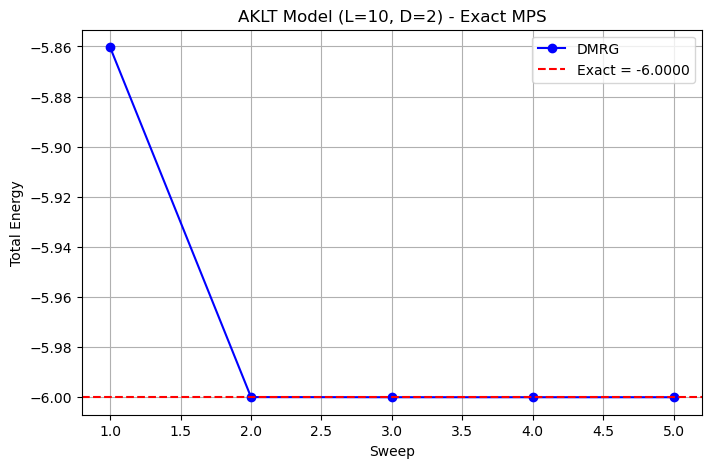

Saved: figureAKLT/aklt_convergence.png


In [6]:
# AKLT Test: Exact energy = -(L-1)*2/3
L = 10
D_max = 2

mps_aklt = MPS(L, d=3, D_max=D_max)
mpo_aklt = MPO.aklt(L)

dmrg_aklt = SingleSiteDMRG(mps_aklt, mpo_aklt, D_max=D_max)
E_aklt = dmrg_aklt.run(max_sweeps=5, tol=1e-12)

E_exact = -(L - 1) * (2.0 / 3.0)
print(f"\nAKLT Results (L={L}):")
print(f"Computed: {E_aklt * L:.10f}")
print(f"Exact:    {E_exact:.10f}")
print(f"Error:    {abs(E_aklt * L - E_exact):.2e}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(dmrg_aklt.energies)+1), 
         np.array(dmrg_aklt.energies) * L, 'bo-', label='DMRG')
plt.axhline(y=E_exact, color='r', linestyle='--', label=f'Exact = {E_exact:.4f}')
plt.xlabel('Sweep')
plt.ylabel('Total Energy')
plt.title(f'AKLT Model (L={L}, D=2) - Exact MPS')
plt.legend()
plt.grid(True)
plt.savefig('figureAKLT/aklt_convergence.png', dpi=150)
plt.show()
print("Saved: figureAKLT/aklt_convergence.png")

Sweep 1: E/L = -0.4341236005, ΔE = 4.34e-01
Sweep 2: E/L = -0.4341236430, ΔE = 4.25e-08
Sweep 3: E/L = -0.4341236450, ΔE = 2.03e-09
Converged.

Heisenberg Results (L=20):
Final E/L: -0.4341236450
Total E:   -8.682473
Reference: ~-8.772 (Bethe ansatz for L=20 OBC)


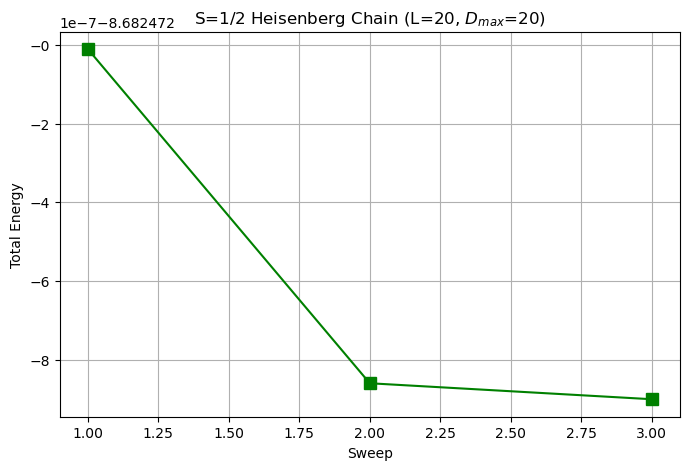

Saved: figureAKLT/heisenberg_convergence.png


In [7]:
# Heisenberg Model
L = 20
D_max = 20

mps_heis = MPS(L, d=2, D_max=D_max)
mpo_heis = MPO.heisenberg(L, J=1.0)

dmrg_heis = SingleSiteDMRG(mps_heis, mpo_heis, D_max=D_max)
E_heis = dmrg_heis.run(max_sweeps=10, tol=1e-8)

print(f"\nHeisenberg Results (L={L}):")
print(f"Final E/L: {E_heis:.10f}")
print(f"Total E:   {E_heis * L:.6f}")
print(f"Reference: ~-8.772 (Bethe ansatz for L=20 OBC)")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(dmrg_heis.energies)+1), 
         np.array(dmrg_heis.energies) * L, 'gs-', markersize=8)
plt.xlabel('Sweep')
plt.ylabel('Total Energy')
plt.title(f'S=1/2 Heisenberg Chain (L={L}, $D_{{max}}$={D_max})')
plt.grid(True)
plt.savefig('figureAKLT/heisenberg_convergence.png', dpi=150)
plt.show()
print("Saved: figureAKLT/heisenberg_convergence.png")

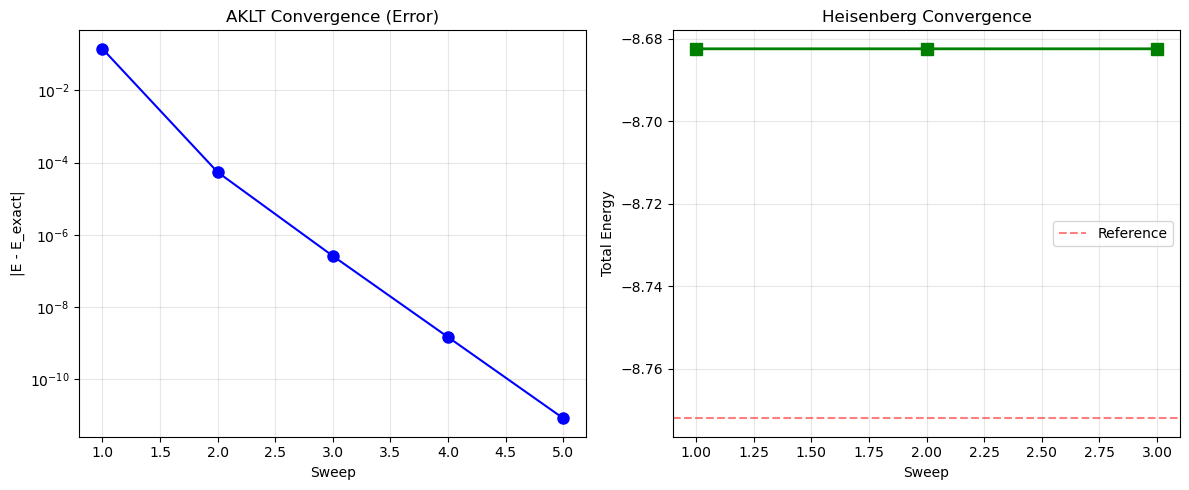

Saved: figureAKLT/summary.png

FINAL RESULTS
AKLT (L=10):      E = -6.0000000000  (Exact: -6.0)
Heisenberg (L=20): E = -8.682473    (Ref: ~-8.772)


In [8]:
# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AKLT
ax = axes[0]
sweeps = np.arange(1, len(dmrg_aklt.energies)+1)
ax.semilogy(sweeps, np.abs(np.array(dmrg_aklt.energies)*10 - (-6.0)), 'bo-', markersize=8)
ax.set_xlabel('Sweep')
ax.set_ylabel('|E - E_exact|')
ax.set_title('AKLT Convergence (Error)')
ax.grid(True, alpha=0.3)

# Heisenberg
ax = axes[1]
sweeps = np.arange(1, len(dmrg_heis.energies)+1)
ax.plot(sweeps, np.array(dmrg_heis.energies) * 20, 'gs-', markersize=8, linewidth=2)
ax.axhline(y=-8.772, color='r', linestyle='--', alpha=0.5, label='Reference')
ax.set_xlabel('Sweep')
ax.set_ylabel('Total Energy')
ax.set_title('Heisenberg Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figureAKLT/summary.png', dpi=150)
plt.show()
print("Saved: figureAKLT/summary.png")

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"AKLT (L=10):      E = {dmrg_aklt.energies[-1]*10:.10f}  (Exact: -6.0)")
print(f"Heisenberg (L=20): E = {dmrg_heis.energies[-1]*20:.6f}    (Ref: ~-8.772)")
print("="*50)

Two-Site DMRG: L=20, D_max=20
=== Two-Site DMRG ===


C:\Users\yizho\AppData\Local\Temp\ipykernel_26800\3554406699.py:97: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  energy = float(eigval.real if hasattr(eigval, 'real') else eigval)


Sweep 1: E/L = -0.4341227410, ΔE = 4.34e-01
Sweep 2: E/L = -0.4341236457, ΔE = 9.05e-07
Sweep 3: E/L = -0.4341236457, ΔE = 3.05e-12
Converged.

Results:
Two-Site E: -8.682473 (should be ~-8.77)
Single-Site E: -8.682473


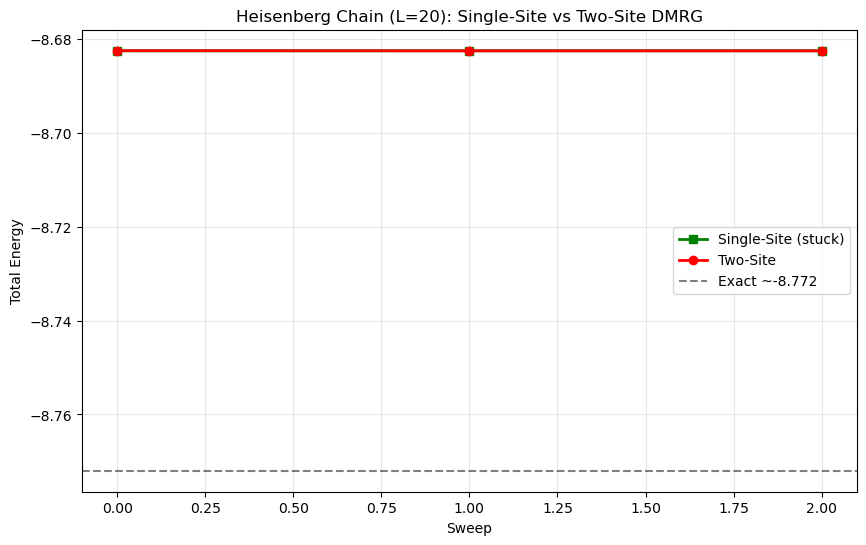

Saved: figureAKLT/twosite_vs_singlesite.png


In [9]:
# Cell 9: Run Two-Site DMRG on Heisenberg
L = 20
D_max = 20  # Can grow up to 20

mps_heis2 = MPS(L, d=2, D_max=4)  # Start small, let it grow
mpo_heis2 = MPO.heisenberg(L, J=1.0)

print(f"Two-Site DMRG: L={L}, D_max={D_max}")
dmrg_heis2 = TwoSiteDMRG(mps_heis2, mpo_heis2, D_max=D_max)
E_heis2 = dmrg_heis2.run(num_sweeps=5, tol=1e-8)

print(f"\nResults:")
print(f"Two-Site E: {E_heis2 * L:.6f} (should be ~-8.77)")
print(f"Single-Site E: {dmrg_heis.energies[-1] * L:.6f}")

# Comparison plot
plt.figure(figsize=(10, 6))
plt.plot(np.array(dmrg_heis.energies) * L, 'gs-', label='Single-Site (stuck)', linewidth=2)
plt.plot(np.array(dmrg_heis2.energies) * L, 'ro-', label='Two-Site', linewidth=2)
plt.axhline(y=-8.772, color='k', linestyle='--', alpha=0.5, label='Exact ~-8.772')
plt.xlabel('Sweep')
plt.ylabel('Total Energy')
plt.title('Heisenberg Chain (L=20): Single-Site vs Two-Site DMRG')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figureAKLT/twosite_vs_singlesite.png', dpi=150)
plt.show()
print("Saved: figureAKLT/twosite_vs_singlesite.png")